In [ ]:
import pickle
import numpy as np
from pathlib import Path
from tqdm import tqdm
from vebir.interference_models.pca import loo_pca, malinowski_ind, pca
from vebir.absorbance_estimators.ebs import EBS
from vebir.absorbance_estimators.solvers import map_als, map_pb, pb_loss, als_loss
from vebir.absorbance_estimators.veb import VEB, norm_cdf, norm_pdf
from vebir.utils.metrics import compute_correlation_metrics, correlation_metrics_to_df
import pandas as pd 
from vebir.utils.distribute import distribute_veb

import matplotlib.pyplot as plt
import multiprocessing as mp
from scipy.optimize import minimize
import cvxpy as cp

from scipy.linalg import svd
from scipy.stats import norm

def bootstrap_sample(Z):
    idx = np.random.choice(Z.shape[0], size=Z.shape[0], replace=True)
    return Z[idx]

def pca_bootstrap(y, Z, tau, sigma, c, B=100, loss = "PB",verbose=False):
    
    boot_x = []
    boot_a = []
    mod = VEB(c=c, loss = loss)
    
    for b in range(B):
        Zb = bootstrap_sample(Z)
        mub, _, _, Wb = pca(Zb)
        Wb = Wb[:,:c]
        
        mod.tau = tau
        mod.sigma_hat = sigma
        
        mod.map(y,mub,Wb)

        boot_x.append(mod.x)
        boot_a.append(y-mod.interference)
        
    boot_x = np.array(boot_x)
    boot_a = np.array(boot_a)
        
    return boot_x, boot_a

In [11]:
REPO_ROOT = Path.cwd().resolve().parent
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"

GT_DIR = REPO_ROOT / "data" / "spectrabase" / "teflon"
LAB_DIR = REPO_ROOT / "data" / "raw" / "teflon" / "laboratory_samples"
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"
CORRECTIONS_DIR = REPO_ROOT / "data" / "corrections" / "teflon" / "veb" / "pb"

with open(PREPROC_DIR / "raw_spectra_dict.pkl", "rb") as f:
    raw_spectra_dict = pickle.load(f)
    
with open(PREPROC_DIR / "blanks_dict.pkl", "rb") as f:
    blanks_dict = pickle.load(f)
    
with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    veb_pb_dict = pickle.load(f)
    
blanks_id = blanks_dict["2011"].copy().index.tolist()
Z = np.array(blanks_dict["2011"])   
chat_cv = loo_pca(Z)[1]
mu, _, _, W = pca(Z)
W = W[:,:chat_cv]

wn = np.sort(pd.read_csv(LAB_DIR / "zerofilling.txt", header=None).iloc[:, 0])

In [19]:
boot_dict = {}
for comp in ["12-Tricosanone","Ammonium sulfate","Suberic Acid","levoglucosan"]:
    boot_dict[comp] = veb_pb_dict[comp]

In [ ]:
alpha = 0.01
for comp in boot_dict.keys():
    for correction in boot_dict[comp]:
        sample_id,tau,sigma = correction["sample_id"], correction["tau"], correction["sigma_hat"]
        y = np.array(raw_spectra_dict[comp]["raw"].loc[sample_id])
        boot_x, boot_a, LOD = pca_bootstrap(y, Z, tau, sigma, c = chat_cv, B=100, loss = "PB",verbose=False)
        
        correction["boot_x"] = boot_x
        correction["boot_a"] = boot_a
        
        r = correction["absorbance"] - boot_a
        stdev = np.std(boot_a, axis=0)
        crit = np.quantile(np.max(r/stdev,axis=0), 1-alpha)
        
        correction["LOD"] = crit*stdev

KeyboardInterrupt: 

In [172]:
with open("boot_dict.pkl", "wb") as f:
    pickle.dump(boot_dict, f)

In [ ]:
for comp in boot_dict.keys():
    for correction in boot_dict[comp]:
        boot_a = correction["boot_a"]
        a = correction["absorbance"]
        
        r = correction["absorbance"] - boot_a
        stdev = np.std(boot_a, axis=0)
        crit = np.quantile(np.max(r/stdev,axis=0), 0.99)
        
        correction["LOD"] = crit*stdev

In [173]:
with open("boot_dict.pkl", "rb") as f:
    boot_dict = pickle.load(f)

In [150]:
stdev

array([0.00146905, 0.0014247 , 0.00135092, ..., 0.00210937, 0.00211897,
       0.00212851], shape=(2785,))

In [174]:
comp = "levoglucosan"

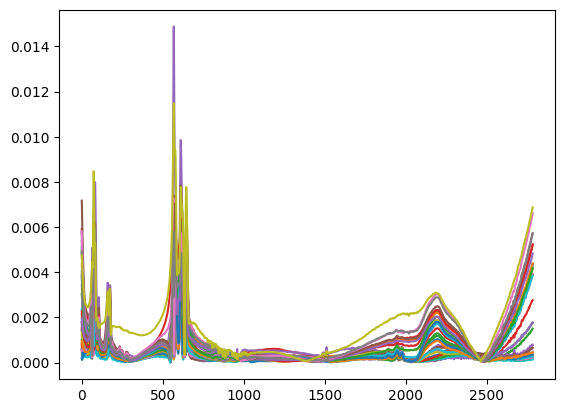

In [175]:
LOD = []
for correction in boot_dict[comp]:
    plt.plot(correction["LOD"])
    LOD.append(correction["LOD"])

In [153]:
LOD = np.array(LOD)

In [154]:
np.argsort(np.max(LOD, axis=1))

array([13,  3, 18,  1,  9,  4, 19, 14, 11,  5,  8, 16, 20, 22,  2, 10, 23,
       12, 17, 15,  6,  7,  0, 21])

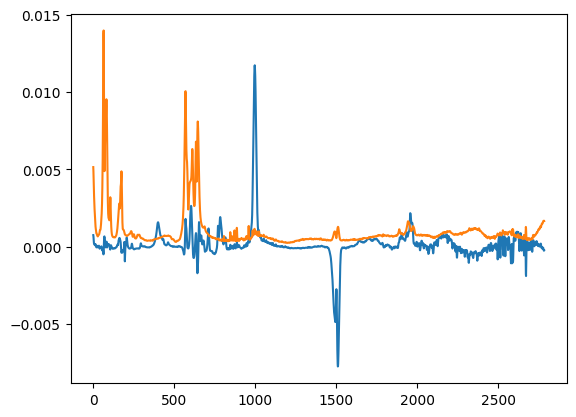

In [158]:
plt.plot(boot_dict[comp][0]["absorbance"])
plt.plot(boot_dict[comp][0]["LOD"])

In [43]:
LOD = crit*stdev

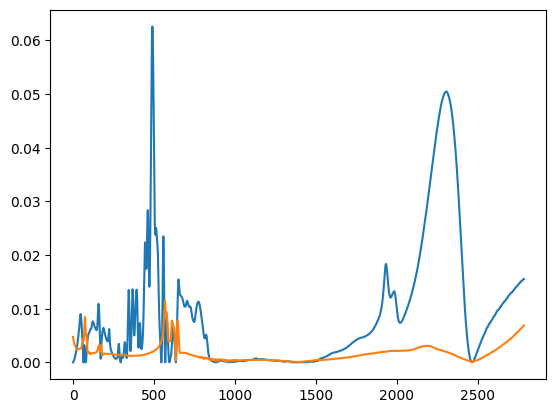

In [45]:
plt.plot(correction["absorbance"])
plt.plot(LOD)

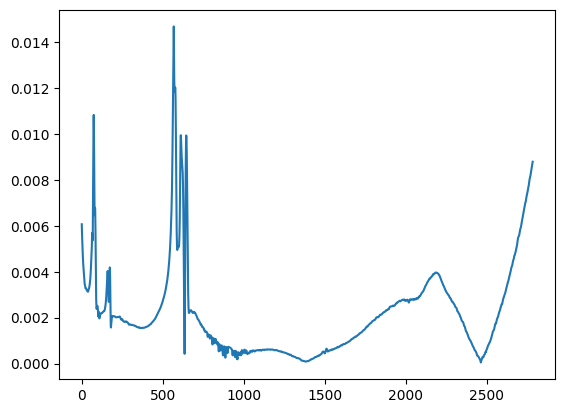

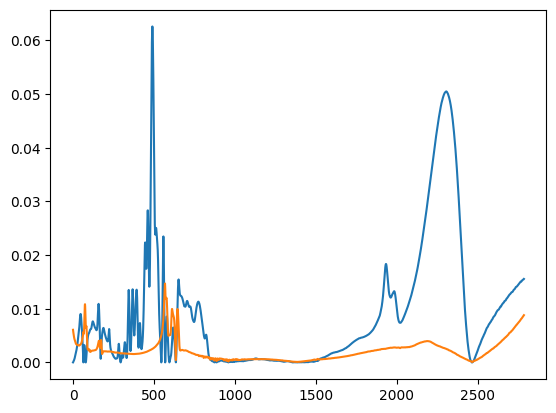

In [23]:
plt.plot(correction["absorbance"])
plt.plot(correction["LOD"])

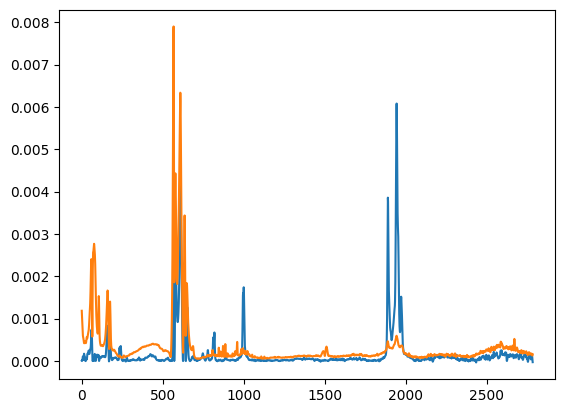

In [14]:
plt.plot(boot_dict[comp][0]["absorbance"])
plt.plot(boot_dict[comp][0]["LOD"])

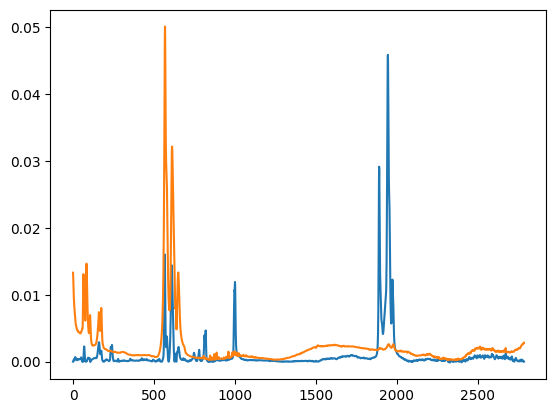

In [15]:
plt.plot(boot_dict[comp][1]["absorbance"])
plt.plot(boot_dict[comp][1]["LOD"])


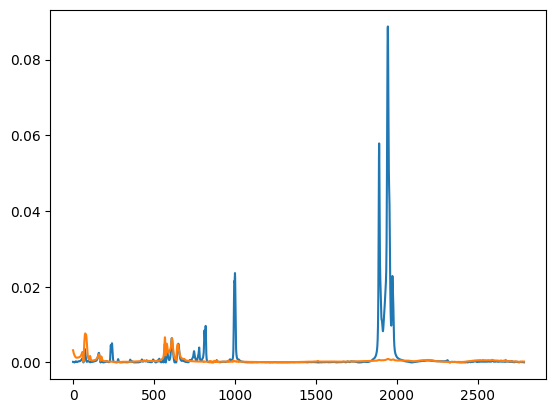

In [17]:
plt.plot(boot_dict[comp][2]["absorbance"])
plt.plot(boot_dict[comp][2]["LOD"])

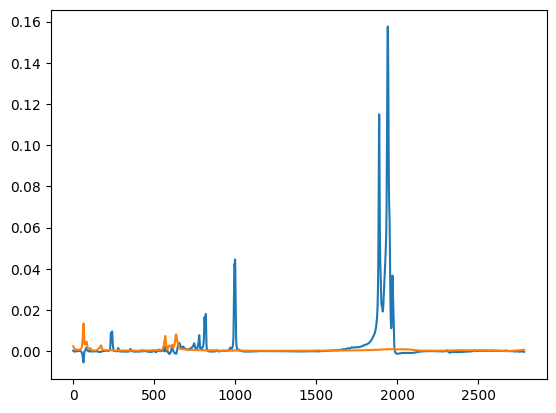

In [18]:
plt.plot(boot_dict[comp][3]["absorbance"])
plt.plot(boot_dict[comp][3]["LOD"])

In [361]:
LOD1 = correction["absorbance"] - np.quantile(boot_a, 0, axis=0)

In [352]:
correction["boot_x"]

KeyError: 'boot_x'

In [344]:
comp = "Ammonium sulfate"

In [ ]:
for correction in :
    print(f"Processing {comp}...")
    break
    

Processing Ammonium sulfate...


In [263]:
correction = veb_pb_dict[comp][5]

100%|██████████| 100/100 [00:43<00:00,  2.29it/s]


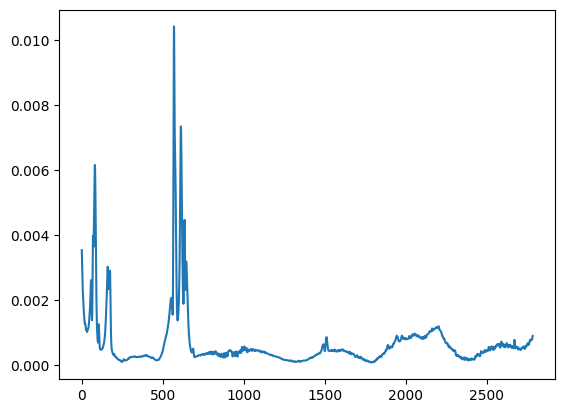

In [342]:
plt.plot(LOD, label="LOD")

In [ ]:
B = 100
boot_x = []
boot_z = []
mod = VEB(c=Wb.shape[1], loss = "PB")

In [285]:
for b in tqdm(range(B)):
    Zb = bootstrap_sample(Z)
    mub, _, _, Wb = pca(Zb)
    Wb = Wb[:,:chat_cv]
    
    mod.tau = tau
    mod.sigma_hat = sigma
    
    mod.map(y,mub,Wb)


    boot_x.append(mod.x)
    boot_z.append(mod.interference)
    
boot_x = np.array(boot_x)
boot_z = np.array(boot_z)

100%|██████████| 1000/1000 [07:52<00:00,  2.12it/s]


In [336]:
LOD = correction["absorbance"] - np.quantile(boot_a, 0.01/y.shape[0], axis=0)

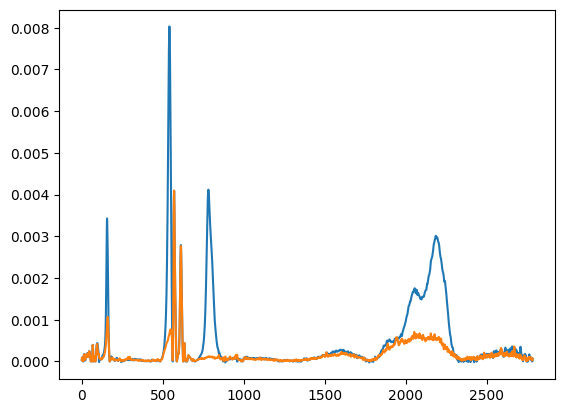

In [337]:
plt.plot(correction["absorbance"])
plt.plot(LOD)

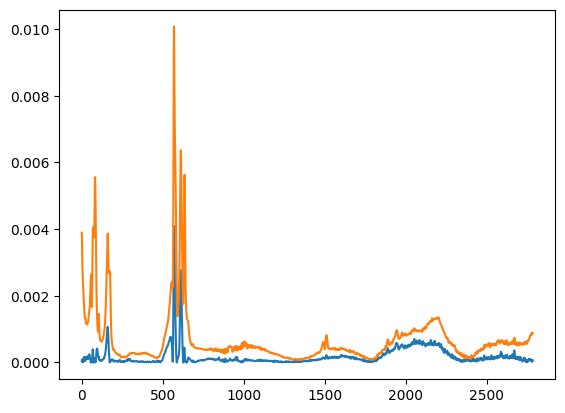

In [339]:
plt.plot(LOD)
plt.plot(np.std(boot_a, axis=0)*zval)

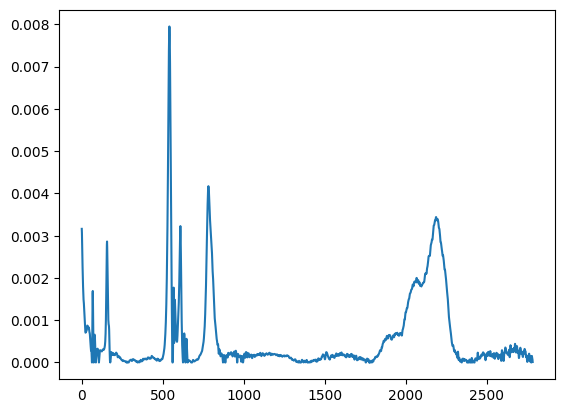

In [316]:
above_lod = correction["absorbance"] - LOD
above_lod[above_lod < 0] = 0
plt.plot(above_lod, label="Above LOD")

(array([ 1.,  0.,  0.,  2.,  2.,  1.,  3.,  6., 25., 60.]),
 array([-0.08867645, -0.08814411, -0.08761176, -0.08707942, -0.08654708,
        -0.08601473, -0.08548239, -0.08495005, -0.0844177 , -0.08388536,
        -0.08335302]),
 <BarContainer object of 10 artists>)

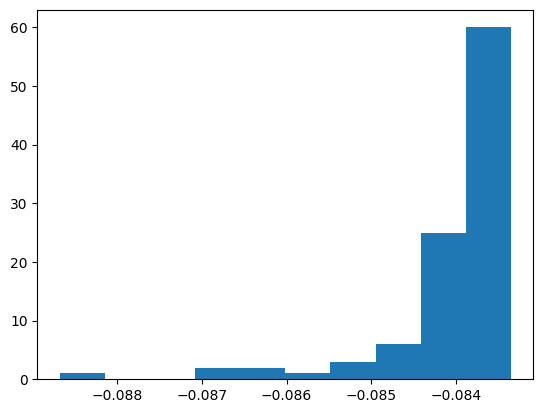

In [276]:
plt.hist(boot_z[:,0],bins=10)

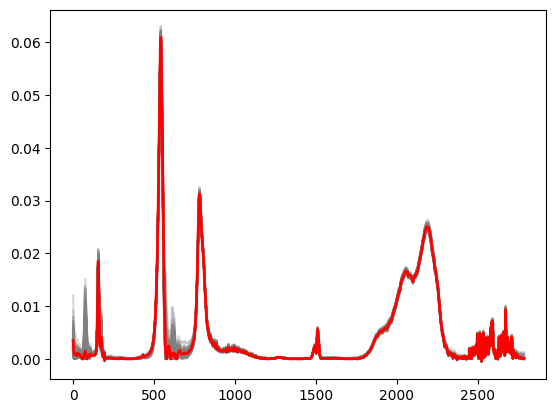

In [230]:
for z in boot_z:
    plt.plot(y-z,c='gray',alpha=0.3)
    
plt.plot(correction["absorbance"],c='red',linewidth=2)

(array([72., 19.,  3.,  2.,  0.,  0.,  2.,  1.,  0.,  1.]),
 array([-7.21792487e-11,  6.08788557e-04,  1.21757719e-03,  1.82636582e-03,
         2.43515445e-03,  3.04394307e-03,  3.65273170e-03,  4.26152033e-03,
         4.87030896e-03,  5.47909759e-03,  6.08788622e-03]),
 <BarContainer object of 10 artists>)

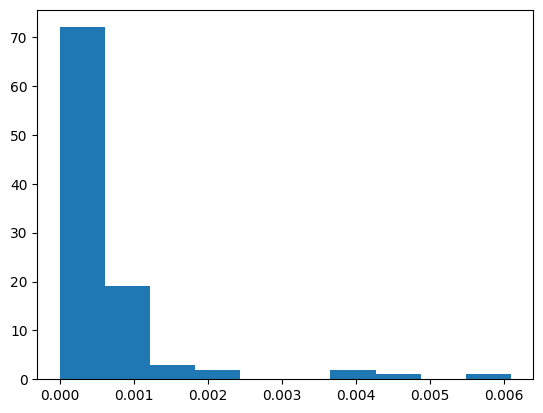

In [222]:
plt.hist(y[0] - boot_z[:,0])

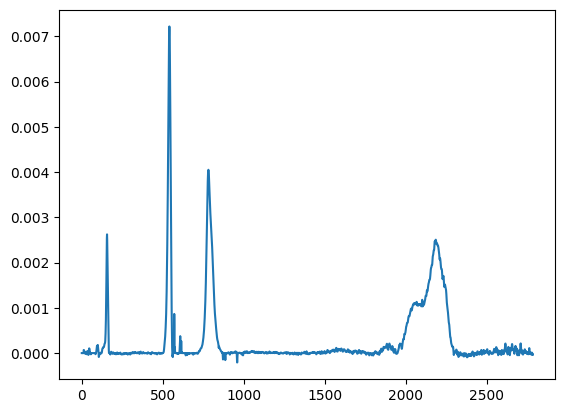

In [195]:
boot_mean = np.mean(boot_z, axis=0)

(array([ 1.,  2.,  0.,  1.,  3.,  2.,  2.,  8., 17., 64.]),
 array([-0.01578369, -0.01398592, -0.01218815, -0.01039038, -0.00859261,
        -0.00679484, -0.00499707, -0.0031993 , -0.00140153,  0.00039624,
         0.00219401]),
 <BarContainer object of 10 artists>)

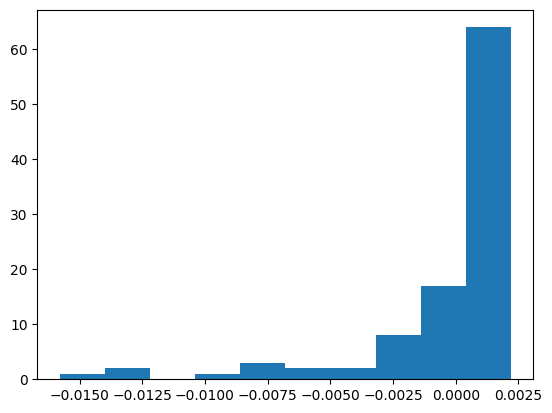

In [200]:
plt.hist((boot_z - boot_mean)[:,0])

In [192]:
LOD = np.quantile(boot_z, 0.05, axis=0)

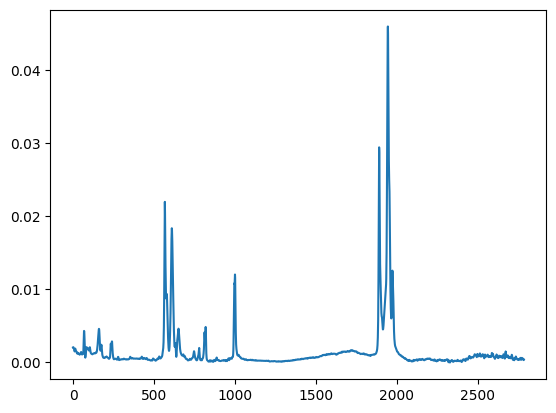

In [196]:
plt.plot(y-boot_mean)

In [183]:
LOD = np.std(boot_z, axis=0)*zval 

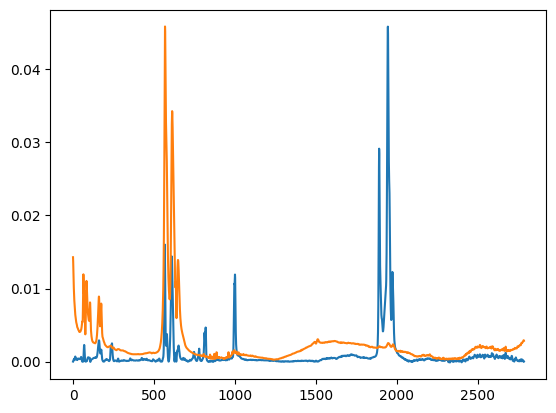

In [184]:
plt.plot(correction["absorbance"], label="Corrected Spectrum")
plt.plot(LOD, label="LOD")

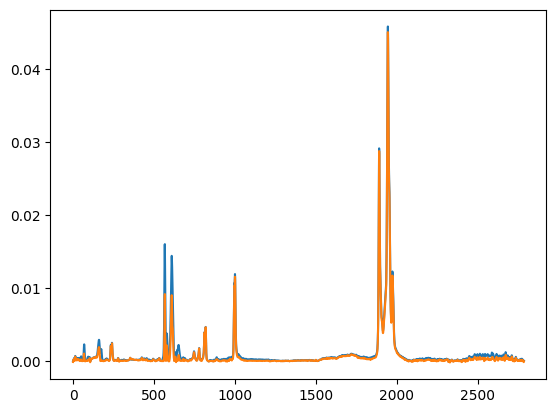

In [181]:
plt.plot(correction["absorbance"], label="Corrected Spectrum")
plt.plot(LOD, label="LOD")

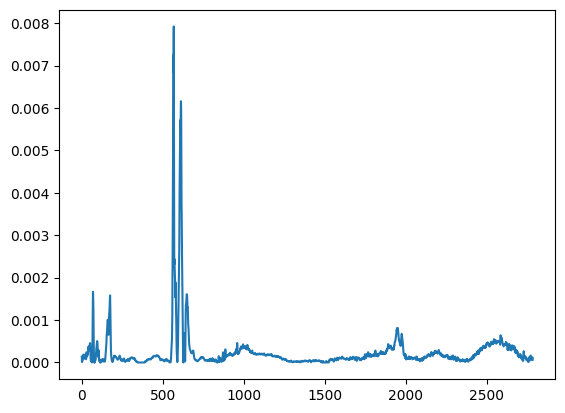

In [164]:
boot_z.shape

(100, 2785)

(array([55436., 42360., 29015., 26649., 26405., 28548., 33742., 32345.,
         1747.,  2253.]),
 array([-0.12261225,  0.03003738,  0.182687  ,  0.33533663,  0.48798625,
         0.64063588,  0.7932855 ,  0.94593513,  1.09858475,  1.25123438,
         1.403884  ]),
 <BarContainer object of 10 artists>)

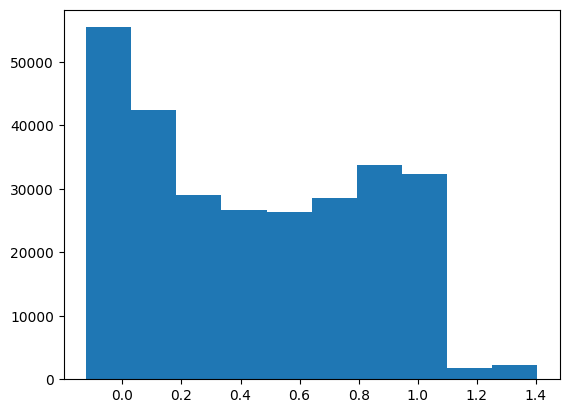

In [169]:

plt.hist(boot_z.flatten())

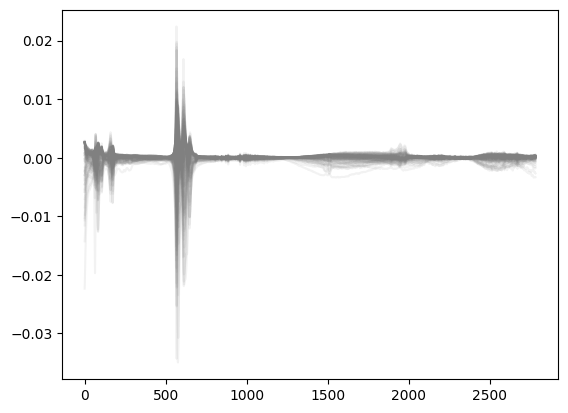

In [167]:
for z in boot_z:
    plt.plot(z- np.mean(boot_z, axis=0), color="gray", alpha=0.1)

In [66]:
mod.x

array([ 9.43160325e-01,  2.16102857e+00, -4.81155731e-01, -4.94490005e+00,
        4.84346241e-01, -3.22716907e+00,  5.12016733e-01,  5.83665455e-01,
        1.08032081e+01, -3.69621634e+00, -9.20312389e-01,  4.77437303e+00,
       -1.93798694e+00, -5.44172663e+00,  6.07023794e+00, -9.98142162e-01,
       -1.44309066e-01,  1.39626238e+00,  4.73584997e+00, -1.91517811e+00,
       -2.05807400e+00, -7.31556221e+00, -2.73840871e+00,  4.57559134e+00,
        2.96586715e+00,  4.82453825e+00,  4.63480318e+00, -1.97448765e+00,
        4.85322178e+00,  4.31954590e+00, -2.95057522e-11, -8.83587298e-13,
       -1.33305387e-12,  4.77418326e-13,  5.11462298e-13,  1.53701060e-12,
       -2.84830850e-12, -1.80400102e-12,  1.33527351e-12,  5.20167195e-12,
        5.71184624e-12, -7.83879217e-12, -2.10961089e-12, -2.77200088e-12,
        5.59747323e-13, -7.71758727e-12, -4.40504760e-12])

In [45]:
Zb[1,:]

array([-0.06819209, -0.06819084, -0.06813918, ...,  0.47799557,
        0.47826094,  0.47852738], shape=(2785,))

In [46]:
Zb[49,:]

array([-0.06819209, -0.06819084, -0.06813918, ...,  0.47799557,
        0.47826094,  0.47852738], shape=(2785,))

In [28]:
sample_id

'01324.dpt'

In [ ]:
mod.map(y,mu,W[:, :chat_cv])

In [ ]:


# Bootstrap sample
Z_boot = Z[indices]

NameError: name 'n_samples' is not defined